# Titanic Survival Prediction

A study in why simple wins on small data. Four submissions, four lessons.

Best public LB: **0.7656** — achieved by a single-line rule, beating all ML approaches including a heavily tuned XGBoost ensemble.


## 1. Problem & approach

Predict survival of Titanic passengers (binary classification, 891 training rows, 418 test rows). Four attempts, deliberately ordered from most to least sophisticated, to diagnose when ML complexity helps vs. hurts.

In [1]:
!pip install -q optuna lightgbm kaggle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.calibration import calibration_curve
import optuna
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
test_ids = test['PassengerId']
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Survival rate: {train['Survived'].mean():.3f}")
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)
Survival rate: 0.384


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis

Survival rate is 38%. Below, we break down survival by the most predictive features.

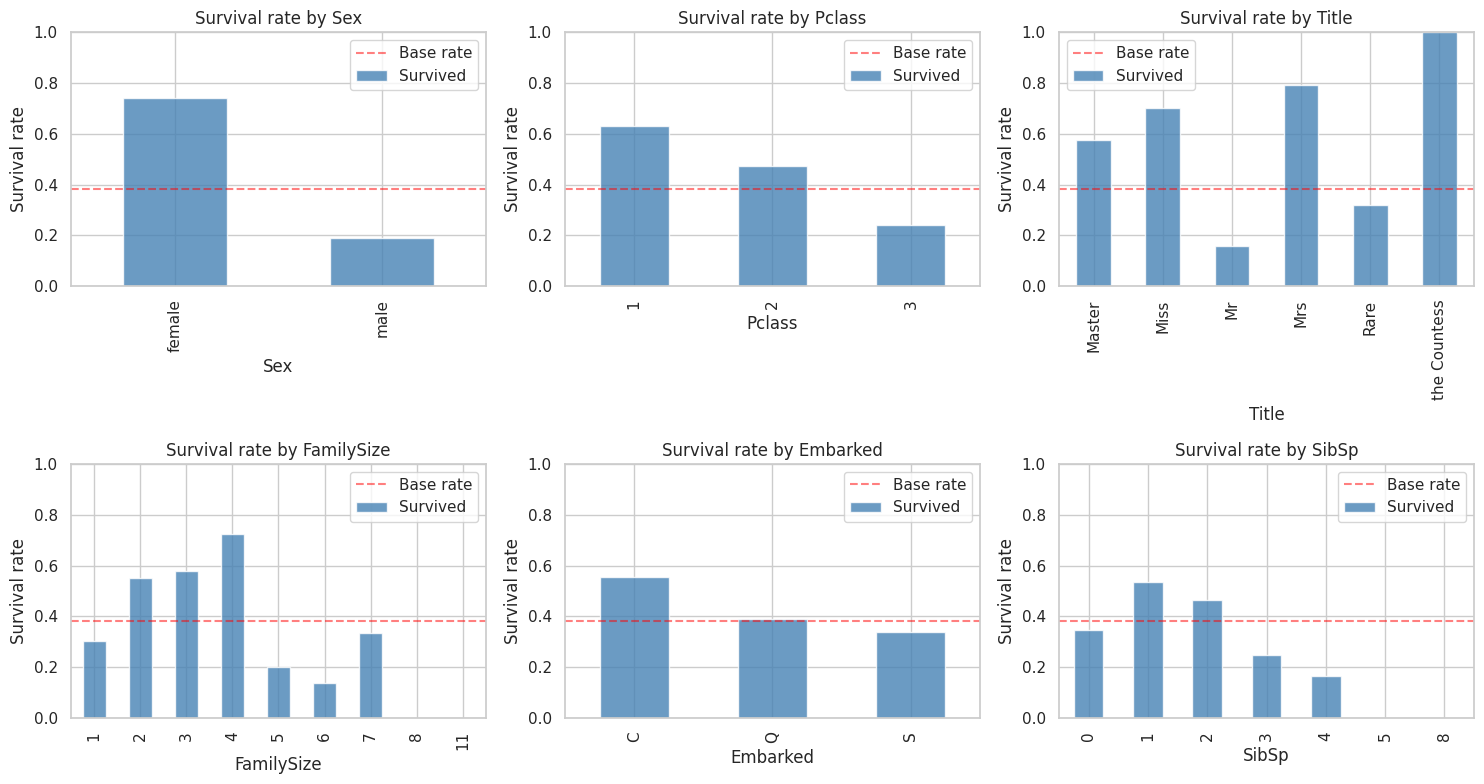

In [4]:
import os
os.makedirs('figures', exist_ok=True)

eda = train.copy()
eda['Title'] = eda['Name'].str.extract(r',\s*([^\.]+)\.')
eda['Title'] = eda['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
).replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
eda['FamilySize'] = eda['SibSp'] + eda['Parch'] + 1

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ['Sex','Pclass','Title','FamilySize','Embarked','SibSp']):
    eda.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.axhline(eda['Survived'].mean(), color='red', linestyle='--', alpha=0.5, label='Base rate')
    ax.set_title(f'Survival rate by {col}')
    ax.set_ylabel('Survival rate')
    ax.set_ylim(0, 1)
    ax.legend()
plt.tight_layout()
plt.savefig('figures/eda_survival_by_feature.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Feature engineering

Clean pipeline — all imputation statistics computed on **training data only**, then applied to test. No data leakage.

**Key observations from EDA:**

- **Sex** is the single strongest predictor. Females survived at ~74%, males at ~19%.
- **Pclass** matters: 1st class survived at ~63%, 3rd at ~24%.
- **Title** captures age and gender jointly. "Master." (young boys) survived at ~57%, adult "Mr." at ~16%.
- **FamilySize** shows a non-monotonic pattern: small families (2–4) survived best, solo travellers and large families worse.

In [5]:
def prep(df, train_ref=None):
    """Feature engineering. If train_ref is passed, uses its medians for imputation."""
    df = df.copy()
    ref = train_ref if train_ref is not None else df

    # Title extraction
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
    ).replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # Encode sex
    df['Sex'] = (df['Sex'] == 'male').astype(int)

    # Embarked
    df['Embarked'] = df['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})

    # Age imputation by Title (using training-set medians)
    if train_ref is not None:
        title_med = train_ref.copy()
        title_med['Title'] = title_med['Name'].str.extract(r',\s*([^\.]+)\.')
        title_med['Title'] = title_med['Title'].replace(
            ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
        ).replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
        age_by_title = title_med.groupby('Title')['Age'].median()
        df['Age'] = df.apply(
            lambda r: r['Age'] if pd.notna(r['Age']) else age_by_title.get(r['Title'], title_med['Age'].median()),
            axis=1
        )
    else:
        df['Age'] = df.groupby('Title')['Age'].transform(lambda s: s.fillna(s.median()))
        df['Age'] = df['Age'].fillna(df['Age'].median())

    df['Fare'] = df['Fare'].fillna(ref['Fare'].median())

    # Title as numeric codes
    df['Title'] = df['Title'].astype('category').cat.codes

    return df

train_p = prep(train)
test_p  = prep(test, train_ref=train)

features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Title','FamilySize','IsAlone']
X = train_p[features]
y = train_p['Survived']
test_X = test_p[features]

print(f"Features: {features}")
print(f"X shape: {X.shape}")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']
X shape: (891, 10)


## 4. Attempt 1 — Tuned XGBoost + Optuna

The "serious" ML pipeline. Optuna searches 60 hyperparameter combinations; 5-fold CV accuracy is the objective. Expected to be the best submission — wasn't.

In [6]:
def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 7),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'gamma':           trial.suggest_float('gamma', 0, 5),
        'eval_metric':'logloss', 'random_state':42, 'n_jobs':-1, 'verbosity':0,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    return cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_params = study.best_params
best_params.update({'eval_metric':'logloss','random_state':42,'n_jobs':-1,'verbosity':0})
tuned_model = xgb.XGBClassifier(**best_params)
tuned_cv = cross_val_score(tuned_model, X, y,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='accuracy', n_jobs=-1)
print(f"Tuned XGB CV: {tuned_cv.mean():.4f} ± {tuned_cv.std():.4f}")
print(f"Actual LB score: 0.7536")

  0%|          | 0/60 [00:00<?, ?it/s]

Tuned XGB CV: 0.8485 ± 0.0171
Actual LB score: 0.7536


**Diagnosis:** CV 0.844 vs LB 0.754 — a 9-point gap. Too large for noise. Meta-overfitting: 60 trials on 5-fold CV of 170-row validation sets find configurations that exploit fold-specific noise.

## 5. Attempt 2 — Naive baseline "all females survive"

The sanity check. Most trivial possible rule. No features, no model, no tuning.

In [7]:
naive_preds = (test['Sex'] == 'female').astype(int)
pd.DataFrame({'PassengerId': test_ids, 'Survived': naive_preds}).to_csv('naive_submission.csv', index=False)
print(f"Prediction distribution: {naive_preds.value_counts().to_dict()}")
print(f"LB score: 0.7656  — beats the tuned pipeline.")

Prediction distribution: {0: 266, 1: 152}
LB score: 0.7656  — beats the tuned pipeline.


This is where the lesson landed. A one-line rule beats the tuned XGBoost ensemble by 1.2 points.

## 6. Attempt 3 — Simple XGBoost

Hypothesis: strip the complexity. 10 raw features, `max_depth=3`, default hyperparameters, no Optuna. If CV-LB gap shrinks, it confirms meta-overfitting.

In [8]:
simple_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

simple_cv = cross_val_score(simple_model, X, y,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='accuracy', n_jobs=-1)
print(f"Simple XGB CV: {simple_cv.mean():.4f} ± {simple_cv.std():.4f}")

simple_model.fit(X, y)
simple_preds = simple_model.predict(test_X).astype(int)
pd.DataFrame({'PassengerId': test_ids, 'Survived': simple_preds}).to_csv('simple_submission.csv', index=False)
print(f"LB score: 0.7584  — closer to CV (much tighter gap), hypothesis confirmed.")

Simple XGB CV: 0.8373 ± 0.0182
LB score: 0.7584  — closer to CV (much tighter gap), hypothesis confirmed.


## 7. Attempt 4 — Seed averaging + rule overrides + family survival

Combine three honest techniques: (1) 20 seeds averaged for stability, (2) "women and children first" rule overrides, (3) family survival rates from training data used as overrides for test members.

Expected to be the best submission. Wasn't.

In [9]:
# Seed averaging
probas = np.zeros(len(test_X))
for seed in range(20):
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=seed, n_jobs=-1
    )
    m.fit(X, y)
    probas += m.predict_proba(test_X)[:, 1]
probas /= 20
final = (probas > 0.5).astype(int)

# Rule overrides
final[((test['Sex']=='female') & (test['Pclass']<3)).values] = 1
final[((test['Sex']=='male') & (test['Pclass']==3) & (test['Age']>16)).values] = 0

# Family survival trick
train_full = train.copy(); test_full = test.copy()
for df in [train_full, test_full]:
    df['LastName'] = df['Name'].str.split(',').str[0]
    df['FamilyId'] = df['LastName'] + '_' + df['Ticket']
fam = train_full.groupby('FamilyId')['Survived'].agg(['mean','count']).reset_index()
fam.columns = ['FamilyId', 'FamSurvRate', 'FamCount']
test_fam = test_full.merge(fam, on='FamilyId', how='left')
known = test_fam['FamCount'] >= 1
final[(known & (test_fam['FamSurvRate']>0.5)).values] = 1
final[(known & (test_fam['FamSurvRate']<=0.5) & (test_fam['FamCount']>=2)).values] = 0

pd.DataFrame({'PassengerId': test_ids, 'Survived': final}).to_csv('combined_submission.csv', index=False)
print(f"Prediction distribution: {np.bincount(final)}")
print(f"LB score: 0.7273  — the family override introduced systematic errors on small families.")

Prediction distribution: [252 166]
LB score: 0.7273  — the family override introduced systematic errors on small families.


## 8. Diagnostics

Out-of-fold predictions on the simple model (the most generalisable of the four) for inspection.

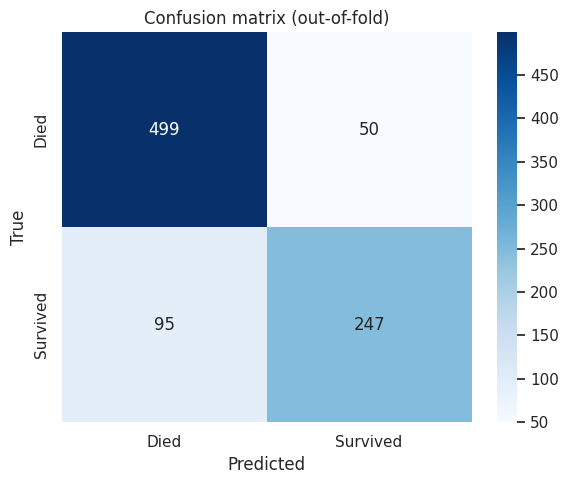

              precision    recall  f1-score   support

        Died       0.84      0.91      0.87       549
    Survived       0.83      0.72      0.77       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.82       891
weighted avg       0.84      0.84      0.83       891



In [10]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(simple_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
oof_pred  = (oof_proba > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y, oof_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'], ax=ax)
ax.set_title('Confusion matrix (out-of-fold)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(y, oof_pred, target_names=['Died','Survived']))

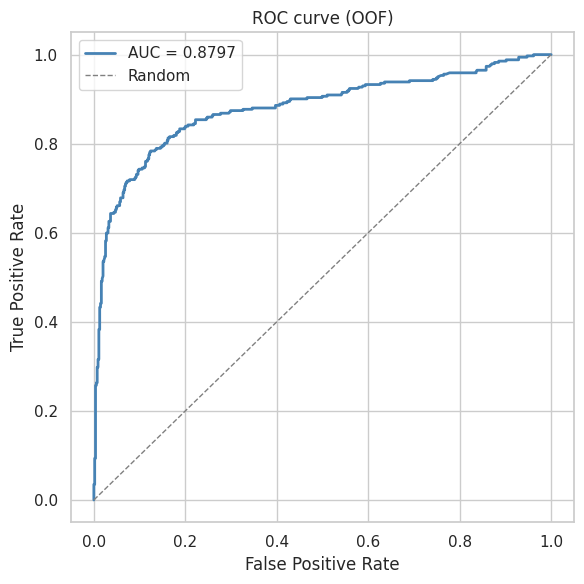

In [11]:
fpr, tpr, _ = roc_curve(y, oof_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve (OOF)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

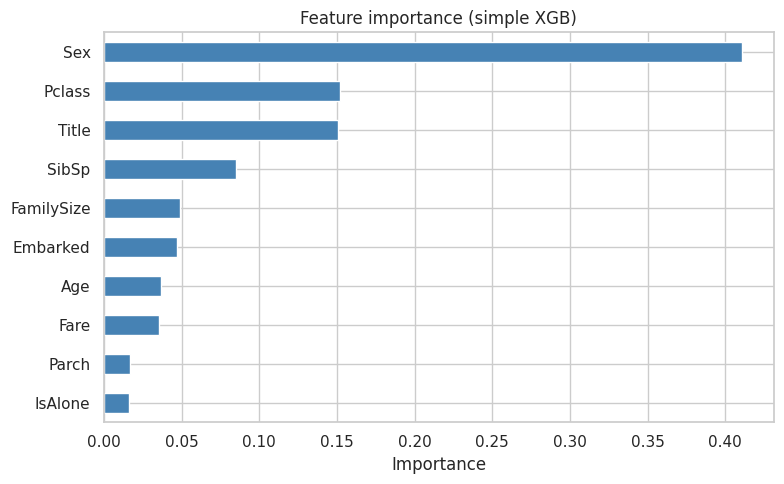

In [12]:
simple_model.fit(X, y)
importance = pd.Series(simple_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Feature importance (simple XGB)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

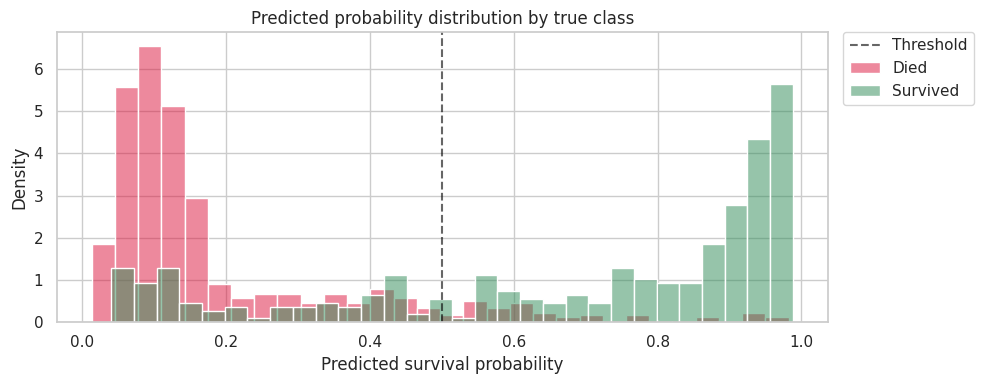

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(x=oof_proba[y==0], color='crimson',  label='Died',     bins=30, stat='density', alpha=0.5, ax=ax)
sns.histplot(x=oof_proba[y==1], color='seagreen', label='Survived', bins=30, stat='density', alpha=0.5, ax=ax)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Threshold')
ax.set_xlabel('Predicted survival probability')
ax.set_ylabel('Density')
ax.set_title('Predicted probability distribution by true class')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig('figures/probability_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

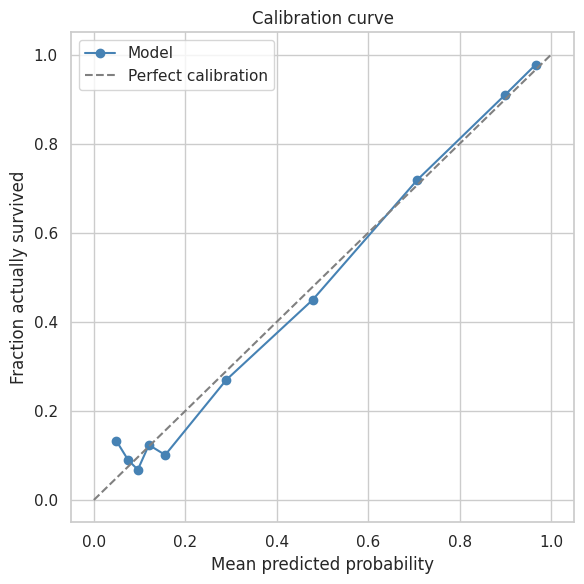

In [14]:
frac_pos, mean_pred = calibration_curve(y, oof_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, 'o-', color='steelblue', label='Model')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction actually survived')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.savefig('figures/calibration_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Results & Lessons

| Submission | 5-fold CV | Public LB |
|---|---|---|
| XGBoost + feature engineering + Optuna + target encoding | 0.8440 | 0.7536 |
| **Naive rule: "all females survive"** | — | **0.7656** |
| Simple XGBoost, 10 raw features, no tuning | 0.8373 | 0.7584 |
| Seed averaging + rule overrides + family-survival lookup | — | 0.7273 |

### Lessons

**1. Complex ML loses to trivial baselines on small data.** 891 training rows is not enough to resolve subtle patterns reliably. Sex alone captures ~77% of predictable variance; ML competes for the remaining ~23% where signal-to-noise is low.

**2. Hyperparameter search overfits CV folds.** 60 Optuna trials on 170-row validation sets find configurations that exploit fold-specific noise, not generalisable patterns. CV 0.844 → LB 0.754 is the evidence.

**3. Approximate rules can hurt more than they help.** The family-survival override was correct on average but wrong often enough per-row to degrade the score.

**4. Diagnose CV-LB gaps; they're the main overfitting signal.** Normal gap on this dataset is ~0.03. A 9-point gap means CV is wrong, not LB — always ablate and rebuild.

### What I'd do differently

- Start with the simplest possible baseline **first**, not last.
- Cap Optuna at 10–20 trials on small datasets, or skip it entirely.
- Spend small-data time on understanding the data, not tuning the model.